In [1]:
from datasets import load_from_disk
import matplotlib.pyplot as plt

In [2]:
og_ds = load_from_disk("datasets_all/all-texts-metadata_topics")

In [3]:
topics = [89, 92, 135]

In [4]:
ds = og_ds.filter(lambda example: example["Topic"] in topics)

Filter:   0%|          | 0/2259336 [00:00<?, ? examples/s]

In [5]:
ds

Dataset({
    features: ['Year', 'Filename', 'CleanedText', 'Source', 'ID', 'SourceCountry', 'SourceLang', 'Topic'],
    num_rows: 9217
})

In [6]:
(len(ds)/len(og_ds))*100

0.4079517167875872

In [7]:
df = ds.to_pandas()

In [8]:
df["Source"] = ["blbooks" if x == "blboooks" else x for x in df["Source"]]

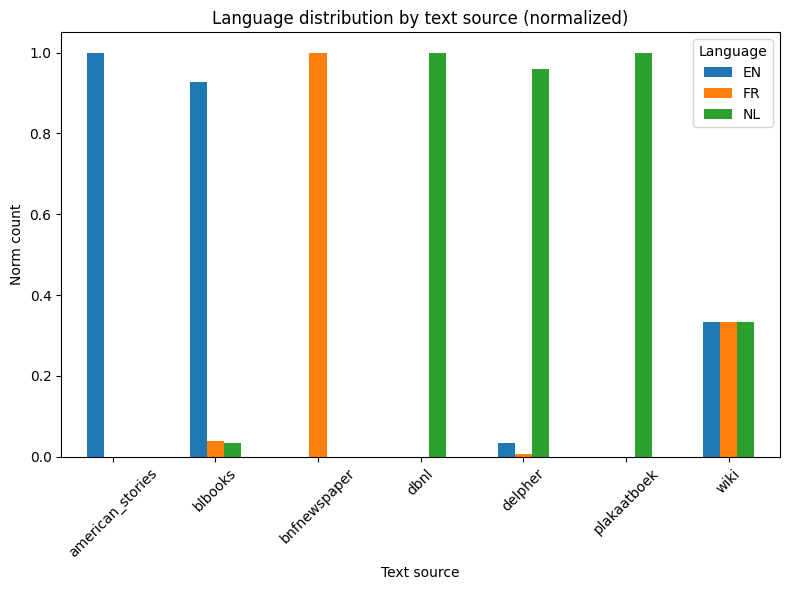

In [9]:
counts = df.groupby(["Source", "SourceLang"]).size().reset_index(name="count")
a = counts.groupby('Source')['count'].transform('sum')
counts['norm_count'] = counts['count'].div(a)

pivot = counts.pivot(index="Source", columns="SourceLang", values="norm_count").fillna(0)
pivot.plot(kind="bar", figsize=(8, 6))

plt.title("Language distribution by text source (normalized)")
plt.xlabel("Text source")
plt.ylabel("Norm count")
plt.xticks(rotation=45)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

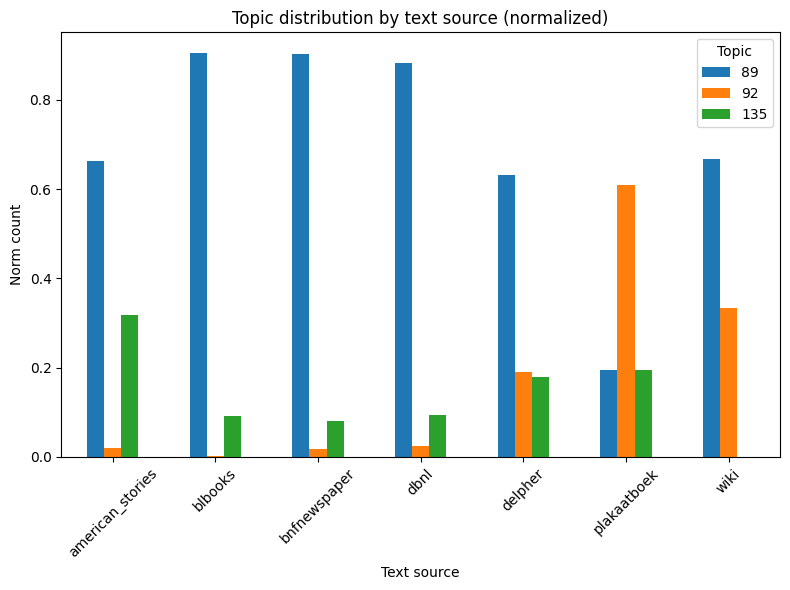

In [10]:
counts = df.groupby(["Source", "Topic"]).size().reset_index(name="count")
a = counts.groupby('Source')['count'].transform('sum')
counts['norm_count'] = counts['count'].div(a)

pivot = counts.pivot(index="Source", columns="Topic", values="norm_count").fillna(0)
pivot.plot(kind="bar", figsize=(8, 6))

plt.title("Topic distribution by text source (normalized)")
plt.xlabel("Text source")
plt.ylabel("Norm count")
plt.xticks(rotation=45)
plt.legend(title="Topic")
plt.tight_layout()
plt.show()